# IN05: Orchestration Patterns Lab -- Sequential, Router, Supervisor


## Objectives

By the end of this notebook you will be able to:

- Implement Sequential, Router, and Supervisor orchestration patterns using LangGraph
- Run identical Walmart customer-support queries through all three patterns
- Measure and compare latency, tool-call count, and routing accuracy across patterns
- Select the right pattern for a given business scenario using a decision rubric

**Use case:** Walmart Customer Support Automation
**Deliverable:** `architecture_comparison_report.txt`

In [1]:
# Three ways of controlling multiple AI steps or agents for a Walmart Customer Support Assistant:
# 1. Sequential pattern
# 2. Router pattern
# 3. Supervisor pattern

In [2]:
import os, json, time
from pathlib import Path
from dotenv import load_dotenv

from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from typing import TypedDict, Annotated, Literal

load_dotenv(override=True)
OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')

llm = ChatOpenAI(model='gpt-4-turbo', api_key=OPENAI_API_KEY, temperature=0)
print('LLM ready:', llm.model_name)

/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


LLM ready: gpt-4-turbo


## Section 1: Three Orchestration Patterns -- Overview

All three patterns use the same four Walmart tools and the same test queries.
The difference is in how control flows between nodes.

| Pattern | Control flow | When to use |
|---|---|---|
| **Sequential** | Fixed pipeline -- steps always run in order | Predictable, auditable workflows with no branching logic |
| **Router** | Single classifier decides which specialist handles the query | Clear intent categories, low overlap between domains |
| **Supervisor** | Orchestrator node decides next worker after each step | Complex, multi-step tasks; can re-route or retry |

**Lab design:** Each pattern answers the same 5 Walmart support queries.
After all three run, we compare latency, tool calls, and response quality.

In [3]:
# 1. Sequential Pattern
# Step 1 → Step 2 → Step 3 → Step 4
# Every query follows the same fixed order.
# Example:
# Understand query
# → Call tool
# → Review response
# → Format final answer

# Best used when
# The process is fixed
# Every step must always run
# Auditability is important
# No branching is required

In [4]:
# 2. Router Pattern

# Customer Query
#       ↓
#    Classifier
#    ↙   ↓   ↘
# Product Service Order

# A router first identifies the type of request and sends it to one specialist.

# Best used when
# Query categories are clear
# Business domains have little overlap
# Only one specialist is usually needed

# Example:
# "Is milk available?" → Product specialist
# "Where is my order?" → Order specialist
# "What is the return policy?" → Service specialist

# The router makes one decision at the beginning.

In [5]:
# 3. Supervisor Pattern

# Supervisor
#     ↓
# Worker
#     ↓
# Supervisor
#     ↓
# Next Worker or Finish

# The supervisor checks progress after every step and decides what should happen next.

# Best used when
# The query is complex
# Multiple specialists may be required
# Re-routing or retries may be needed
# The number of steps is not fixed

# Example:
# Customer asks:
# “Is this TV available, and can I return it after 10 days?”

# The supervisor may:
# Send to Product Worker
# → Check availability
# → Return to Supervisor
# → Send to Service Worker
# → Check return policy
# → Finish

| Pattern    | Who controls the flow?              |
| ---------- | ----------------------------------- |
| Sequential | Fixed workflow                      |
| Router     | One classifier at the beginning     |
| Supervisor | Supervisor decides after every step |


## Section 2: Shared Walmart Tools

Same four tools from IN04. Defined once and reused across all three patterns.

In [6]:
@tool
def search_product(query: str) -> str:
    """Search Walmart product catalog. Returns product name, price, aisle, and SKU."""
    catalog = {
        'milk':    'Great Value Whole Milk 1gal    | $3.98 | Aisle 12 | SKU: GV-MILK-1G',
        'bread':   'Great Value White Bread 20oz   | $1.28 | Aisle 8  | SKU: GV-BREAD-20',
        'eggs':    'Great Value Large Eggs 12ct    | $2.68 | Aisle 11 | SKU: GV-EGGS-12',
        'butter':  'Great Value Unsalted Butter 1lb| $4.48 | Aisle 12 | SKU: GV-BUTT-1',
        'chicken': 'Great Value Chicken Breast 3lb | $8.97 | Aisle 4  | SKU: GV-CHKN-3',
    }
    q = query.lower()
    for key, val in catalog.items():
        if key in q:
            return val
    return f'No product found for: {query}'

@tool
def check_inventory(sku: str) -> str:
    """Check real-time inventory for a product SKU at the nearest Walmart store."""
    inventory = {
        'GV-MILK-1G':   'In stock: 24 units | Store 042 Bentonville AR',
        'GV-BREAD-20':  'In stock: 61 units | Store 042 Bentonville AR',
        'GV-EGGS-12':   'Low stock: 5 units | Store 042 | Restock: Tomorrow',
        'GV-BUTT-1':    'In stock: 18 units | Store 042 Bentonville AR',
        'GV-CHKN-3':    'Out of stock | Store 042 | Available for online order',
    }
    return inventory.get(sku.upper(), f'SKU {sku} not found in inventory system')

@tool
def get_policy(policy_type: str) -> str:
    """Retrieve Walmart store policy. Types: returns, shipping, price_match, pickup, grocery."""
    policies = {
        'returns':     '90-day return policy. Receipt required. Electronics: 15 days.',
        'shipping':    'Free 2-day shipping on orders over $35. Same-day in select areas.',
        'price_match': 'Walmart matches Amazon, Target, and major retailers on identical items.',
        'pickup':      'Free curbside pickup. Order by 6pm for same-day at most stores.',
        'grocery':     'Fresh guarantee: full refund on any fresh item if not satisfied.',
    }
    key = policy_type.lower().replace(' ', '_')
    for k, v in policies.items():
        if k in key or key in k:
            return v
    return f'Policy not found: {policy_type}'

@tool
def get_order_status(order_id: str) -> str:
    """Get current status of a Walmart order by order ID."""
    orders = {
        'WM-2024-001': 'Delivered June 28 2026 | 3 items | Total: $24.73',
        'WM-2024-002': 'Out for delivery | ETA: Today by 8pm',
        'WM-2024-003': 'Processing | Payment confirmed | Ships within 24 hours',
        'WM-2024-004': 'Cancelled | Refund of $18.45 issued June 27 2026',
    }
    return orders.get(order_id.upper(), f'Order {order_id} not found')

ALL_TOOLS = [search_product, check_inventory, get_policy, get_order_status]
PRODUCT_TOOLS = [search_product, check_inventory]
SERVICE_TOOLS = [get_policy, get_order_status]

print(f'Tools registered: {[t.name for t in ALL_TOOLS]}')

Tools registered: ['search_product', 'check_inventory', 'get_policy', 'get_order_status']


In [7]:
TEST_QUERIES = [
    'What is the price of milk and is it in stock?',
    'I want to return a TV I bought 10 days ago. What is the return policy?',
    'Check my order WM-2024-002.',
    'Find chicken breast and tell me if I can pick it up today.',
    'Do you price match? I saw eggs cheaper at Target.',
]

print(f'{len(TEST_QUERIES)} test queries defined for all three patterns.')

5 test queries defined for all three patterns.


## Section 3: Pattern 1 -- Sequential

Every query passes through four fixed steps in order, regardless of intent.

```
  [START]
     |
  [classify_intent]    -- LLM labels the query type
     |
  [tool_execution]     -- LLM calls whichever tools are needed
     |
  [quality_check]      -- LLM verifies the answer is grounded
     |
  [format_response]    -- LLM formats the final customer reply
     |
  [END]
```

**When to use Sequential:**
- Regulatory or audit requirements mandate every step is traceable
- Quality gate between retrieval and generation is non-negotiable
- Predictable cost per query (fixed number of LLM calls)

**Trade-off:** Slower than Router (runs all steps even for trivial queries).

In [8]:
# Raw tool:
# In stock: 24 units | Store 042 Bentonville AR
# may become:
# Great Value Whole Milk is currently in stock, with 24 units available at Store 042.

In [9]:
class SeqState(TypedDict):
    messages: Annotated[list, add_messages]
    intent: str
    tool_output: str
    quality_ok: bool # stores whether the generated answer passed the quality check.

llm_all_tools = llm.bind_tools(ALL_TOOLS)

def seq_classify(state: SeqState) -> dict:
    query = state['messages'][-1].content
    resp = llm.invoke([
        SystemMessage(content='Classify this customer query in 3 words or fewer: PRODUCT_LOOKUP, ORDER_STATUS, RETURN_POLICY, PRICE_MATCH, PICKUP_INFO, or OTHER.'),
        HumanMessage(content=query),
    ])
    return {'intent': resp.content.strip()}

def seq_tool_execution(state: SeqState) -> dict:
    query = state['messages'][-1].content
    msgs = [
        SystemMessage(content='You are a Walmart assistant. Use tools to answer the customer query accurately.'),
        HumanMessage(content=query),
    ]
    resp = llm_all_tools.invoke(msgs)
    if hasattr(resp, 'tool_calls') and resp.tool_calls:
        tool_out = ToolNode(ALL_TOOLS).invoke({'messages': [resp]})
        tool_text = ' | '.join(m.content for m in tool_out['messages'] if hasattr(m, 'content'))
        final = llm.invoke(msgs + [resp] + tool_out['messages'])
        return {'tool_output': tool_text, 'messages': [final]}
    return {'tool_output': resp.content, 'messages': [resp]}

def seq_quality_check(state: SeqState) -> dict:
    last = state['messages'][-1].content
    check = llm.invoke([
        SystemMessage(content='Does this response directly answer the customer query? Reply YES or NO only.'),
        HumanMessage(content=f'Query: {state["messages"][0].content}\nResponse: {last}'),
    ])
    return {'quality_ok': 'YES' in check.content.upper()}

def seq_format_response(state: SeqState) -> dict:
    last = state['messages'][-1].content
    if state.get('quality_ok', True):
        return {'messages': [AIMessage(content=last)]}
    fallback = 'I was unable to find a complete answer. Please contact Walmart support at 1-800-WALMART.'
    return {'messages': [AIMessage(content=fallback)]}

seq_graph = StateGraph(SeqState)
seq_graph.add_node('classify',       seq_classify)
seq_graph.add_node('tool_execution', seq_tool_execution)
seq_graph.add_node('quality_check',  seq_quality_check)
seq_graph.add_node('format_response',seq_format_response)
seq_graph.set_entry_point('classify')
seq_graph.add_edge('classify',       'tool_execution')
seq_graph.add_edge('tool_execution', 'quality_check')
seq_graph.add_edge('quality_check',  'format_response')
seq_graph.add_edge('format_response', END)
seq_app = seq_graph.compile()
print('Sequential graph compiled. Nodes:', list(seq_graph.nodes.keys()))

Sequential graph compiled. Nodes: ['classify', 'tool_execution', 'quality_check', 'format_response']


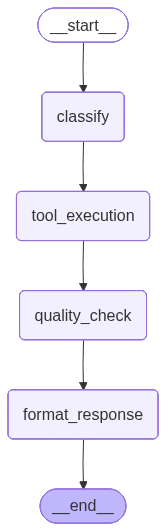

In [10]:
# To see the graph’s connection visually
from IPython.display import Image,display
display(Image(seq_app.get_graph().draw_mermaid_png()))

In [11]:
TEST_QUERIES

['What is the price of milk and is it in stock?',
 'I want to return a TV I bought 10 days ago. What is the return policy?',
 'Check my order WM-2024-002.',
 'Find chicken breast and tell me if I can pick it up today.',
 'Do you price match? I saw eggs cheaper at Target.']

In [13]:
sequential_results = []
print('Pattern 1 -- Sequential')
print('=' * 60)

for i, query in enumerate(TEST_QUERIES, 1):
    start = time.time()
    state = seq_app.invoke({
        'messages': [HumanMessage(content=query)],
        'intent': '', 'tool_output': '', 'quality_ok': True,
    })
    latency = round(time.time() - start, 2)
    final = state['messages'][-1].content
    sequential_results.append({
        'query': query, 'answer': final,
        'latency_sec': latency, 'intent': state.get('intent', '?'),
        'quality_ok': state.get('quality_ok', True),
    })
    print(f'Q{i}: {query}')
    print(f'   Intent  : {state.get("intent", "?")}')
    print(f'   Quality : {"PASS" if state.get("quality_ok", True) else "FAIL"}')
    print(f'   A: {final}')
    print(f'   Latency: {latency}s')
    print()

Pattern 1 -- Sequential
Q1: What is the price of milk and is it in stock?
   Intent  : PRODUCT_LOOKUP
   Quality : PASS
   A: The Great Value Whole Milk (1 gallon) is priced at $3.98 and is available in Aisle 12 at your local Walmart.
   Latency: 6.27s

Q2: I want to return a TV I bought 10 days ago. What is the return policy?
   Intent  : RETURN_POLICY
   Quality : PASS
   A: For electronics, including TVs, Walmart has a 15-day return policy. Since you bought your TV 10 days ago, you can return it within this timeframe. Please make sure to bring your receipt when you return the item.
   Latency: 6.33s

Q3: Check my order WM-2024-002.
   Intent  : ORDER_STATUS
   Quality : PASS
   A: Your order WM-2024-002 is currently out for delivery and is expected to arrive today by 8 PM.
   Latency: 4.4s

Q4: Find chicken breast and tell me if I can pick it up today.
   Intent  : PICKUP_INFO
   Quality : PASS
   A: You can find the Great Value Chicken Breast (3 lb) for $8.97 in Aisle 4. You can pi

## Section 4: Pattern 2 -- Router

A classifier node routes the query to the appropriate specialist agent.
Each specialist has a narrower tool set and a focused system prompt.

```
  [START]
     |
  [classifier]
     |
  PRODUCT? --> [product_handler] --> [END]
  SERVICE? --> [service_handler] --> [END]
  ORDER?   --> [order_handler]   --> [END]
```

**When to use Router:**
- Clear, non-overlapping intent categories
- Want smaller context windows per specialist
- Need to enforce governance: each specialist only sees relevant tools

**Trade-off:** Classification error sends the query to the wrong specialist.
Needs fallback handling for ambiguous queries.

In [16]:
# The Router pattern first classifies the customer query, then sends it to one appropriate specialist.

# START
#   ↓
# Classifier
#   ├── PRODUCT → Product Handler → END
#   ├── SERVICE → Service Handler → END
#   └── ORDER   → Order Handler   → END

# Use the Router pattern when:
# Categories are clear
# Queries normally belong to one domain
# Domains do not overlap much
# You want faster handling than a fixed sequential pipeline

# Example
# Customer asks:
# “Check order WM-2024-002.”
# Flow:
# Classifier → ORDER → Order Handler → get_order_status() → Final answer
# The product and service handlers are never called.


# Main trade-off
# The router makes only one classification decision.
# If it sends a query to the wrong specialist, that specialist may not have the correct tools.
# Example:
# “Find chicken breast and tell me the pickup policy.”
# This query involves both product and service information. A simple router may select only one category and miss part of the request.

# So ambiguous or multi-domain queries need:
# A fallback route
# Reclassification
# Or escalation to a Supervisor pattern

In [17]:
class RouterState(TypedDict):
    messages: Annotated[list, add_messages]
    route: str

ORDER_TOOLS = [get_order_status, get_policy]
llm_product = llm.bind_tools(PRODUCT_TOOLS)
llm_service = llm.bind_tools(SERVICE_TOOLS)
llm_order   = llm.bind_tools(ORDER_TOOLS)

CLASSIFIER_PROMPT = (
    'Classify the customer query into one of three categories. Reply with one word only. '
    'PRODUCT: questions about products, prices, inventory, availability, pickup. '
    'SERVICE: questions about returns, shipping, price match, store policies. '
    'ORDER: questions about order status, tracking, cancellations.'
)

def router_classify(state: RouterState) -> dict:
    query = state['messages'][-1].content
    resp = llm.invoke([
        SystemMessage(content=CLASSIFIER_PROMPT),
        HumanMessage(content=query),
    ])
    word = resp.content.strip().upper()
    if 'ORDER' in word:
        route = 'order'
    elif 'SERVICE' in word:
        route = 'service'
    else:
        route = 'product'
    return {'route': route}

def route_by_intent(state: RouterState) -> str:
    return state['route']

def _router_specialist(state, bound_llm, tools, prompt):
    msgs = [SystemMessage(content=prompt)] + state['messages']
    resp = bound_llm.invoke(msgs)
    if hasattr(resp, 'tool_calls') and resp.tool_calls:
        tool_out = ToolNode(tools).invoke({'messages': [resp]})
        final = llm.invoke(msgs + [resp] + tool_out['messages'])
        return {'messages': [final]}
    return {'messages': [resp]}

def product_handler(state: RouterState) -> dict:
    return _router_specialist(state, llm_product, PRODUCT_TOOLS,
        'You are a Walmart product specialist. Find products and check inventory.')

def service_handler(state: RouterState) -> dict:
    return _router_specialist(state, llm_service, SERVICE_TOOLS,
        'You are a Walmart customer service agent. Handle returns, shipping, and price-match questions.')

def order_handler(state: RouterState) -> dict:
    return _router_specialist(state, llm_order, ORDER_TOOLS,
        'You are a Walmart order management agent. Track orders and explain cancellation/refund policies.')

router_graph = StateGraph(RouterState)
router_graph.add_node('classifier',      router_classify)
router_graph.add_node('product_handler', product_handler)
router_graph.add_node('service_handler', service_handler)
router_graph.add_node('order_handler',   order_handler)
router_graph.set_entry_point('classifier')
router_graph.add_conditional_edges(
    'classifier', route_by_intent,
    {'product': 'product_handler', 'service': 'service_handler', 'order': 'order_handler'},
)
router_graph.add_edge('product_handler', END)
router_graph.add_edge('service_handler', END)
router_graph.add_edge('order_handler',   END)
router_app = router_graph.compile()
print('Router graph compiled. Nodes:', list(router_graph.nodes.keys()))

Router graph compiled. Nodes: ['classifier', 'product_handler', 'service_handler', 'order_handler']


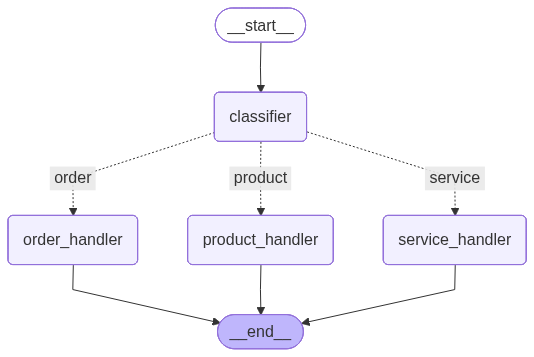

In [18]:
# To see the graph’s connection visually
from IPython.display import Image,display
display(Image(router_app.get_graph().draw_mermaid_png()))

In [19]:
router_results = []
print('Pattern 2 -- Router')
print('=' * 60)

for i, query in enumerate(TEST_QUERIES, 1):
    start = time.time()
    state = router_app.invoke({'messages': [HumanMessage(content=query)], 'route': ''})
    latency = round(time.time() - start, 2)
    final = state['messages'][-1].content
    router_results.append({
        'query': query, 'answer': final,
        'latency_sec': latency, 'route': state.get('route', '?'),
    })
    print(f'Q{i}: {query}')
    print(f'   Route  : {state.get("route", "?").upper()}')
    print(f'   A: {final[:200]}')
    print(f'   Latency: {latency}s')
    print()

Pattern 2 -- Router
Q1: What is the price of milk and is it in stock?
   Route  : PRODUCT
   A: The price of Great Value Whole Milk (1 gallon) is $3.98. It is currently in stock and can be found in Aisle 12.
   Latency: 4.93s

Q2: I want to return a TV I bought 10 days ago. What is the return policy?
   Route  : SERVICE
   A: For TVs, which fall under the electronics category, you have 15 days to return the item from the date of purchase. Since you bought the TV 10 days ago, you are within the return window. Please make su
   Latency: 4.92s

Q3: Check my order WM-2024-002.
   Route  : ORDER
   A: Your order WM-2024-002 is currently out for delivery and is expected to arrive today by 8 PM.
   Latency: 3.86s

Q4: Find chicken breast and tell me if I can pick it up today.
   Route  : PRODUCT
   A: You can pick up the Great Value Chicken Breast (3 lb) today at Walmart. It is priced at $8.97 and located in Aisle 4.
   Latency: 4.07s

Q5: Do you price match? I saw eggs cheaper at Target.
   

## Section 5: Pattern 3 -- Supervisor / Hierarchical

A supervisor node controls the workflow loop.
After each worker finishes, control returns to the supervisor which decides: delegate again, re-route, or finish.

```
  [START]
     |
  [supervisor]  <---------+
     |                    |
  PRODUCT? -> [product_worker] -+
  SERVICE? -> [service_worker] -+
  ORDER?   -> [order_worker]   -+
  FINISH?  -> [END]
```

**When to use Supervisor:**
- Multi-step tasks where the next step depends on the previous result
- Need to retry or re-route if a worker returns an incomplete answer
- Complex queries that span multiple domains (product + policy + order)

**Trade-off:** More LLM calls per query (supervisor + worker(s)).
Higher cost and latency than Router for simple single-domain queries.

In [20]:
# In this pattern, one supervisor agent controls the complete workflow.

# Example query:
# “Find chicken breast, check whether it is available, and explain the pickup policy.”
# The Supervisor may execute:
# Supervisor
# → Product Worker
# → Supervisor
# → Service Worker
# → Supervisor
# → FINISH
# The Supervisor can therefore involve more than one specialist for the same customer query.
    
# Trade-off
# The main disadvantage is additional cost and latency.

In [21]:
class SupervisorState(TypedDict):
    messages: Annotated[list, add_messages]
    next_worker: str
    iteration: int # how many supervisor decisions have happened

SUPERVISOR_PROMPT = (
    'You are a supervisor managing a Walmart customer support team. '
    'Given the conversation so far, decide who should respond next. '
    'Reply with one word: PRODUCT (product/inventory questions), '
    'SERVICE (returns/shipping/policy questions), '
    'ORDER (order status/tracking questions), or FINISH (the question is fully answered). '
    'If the last message is a complete, helpful answer to the customer, reply FINISH.'
)

def supervisor_node(state: SupervisorState) -> dict:
    iteration = state.get('iteration', 0)
    if iteration >= 3:
        return {'next_worker': 'FINISH', 'iteration': iteration + 1}
    resp = llm.invoke([SystemMessage(content=SUPERVISOR_PROMPT)] + state['messages'])
    word = resp.content.strip().upper()
    if 'PRODUCT' in word:
        nxt = 'PRODUCT'
    elif 'ORDER' in word:
        nxt = 'ORDER'
    elif 'SERVICE' in word:
        nxt = 'SERVICE'
    else:
        nxt = 'FINISH'
    return {'next_worker': nxt, 'iteration': iteration + 1}

def supervisor_route(state: SupervisorState) -> str:
    return state.get('next_worker', 'FINISH')

def sv_product_worker(state: SupervisorState) -> dict:
    return _router_specialist(state, llm_product, PRODUCT_TOOLS,
        'You are a Walmart product specialist. Find products and check inventory.')

def sv_service_worker(state: SupervisorState) -> dict:
    return _router_specialist(state, llm_service, SERVICE_TOOLS,
        'You are a Walmart service agent. Handle returns, shipping, and policy questions.')

def sv_order_worker(state: SupervisorState) -> dict:
    return _router_specialist(state, llm_order, ORDER_TOOLS,
        'You are a Walmart order agent. Track orders and explain refund policies.')

sv_graph = StateGraph(SupervisorState)
sv_graph.add_node('supervisor',      supervisor_node)
sv_graph.add_node('product_worker',  sv_product_worker)
sv_graph.add_node('service_worker',  sv_service_worker)
sv_graph.add_node('order_worker',    sv_order_worker)
sv_graph.set_entry_point('supervisor')
sv_graph.add_conditional_edges(
    'supervisor', supervisor_route,
    {
        'PRODUCT': 'product_worker',
        'SERVICE': 'service_worker',
        'ORDER':   'order_worker',
        'FINISH':   END,
    },
)
sv_graph.add_edge('product_worker', 'supervisor')
sv_graph.add_edge('service_worker', 'supervisor')
sv_graph.add_edge('order_worker',   'supervisor')
sv_app = sv_graph.compile()
print('Supervisor graph compiled. Nodes:', list(sv_graph.nodes.keys()))

Supervisor graph compiled. Nodes: ['supervisor', 'product_worker', 'service_worker', 'order_worker']


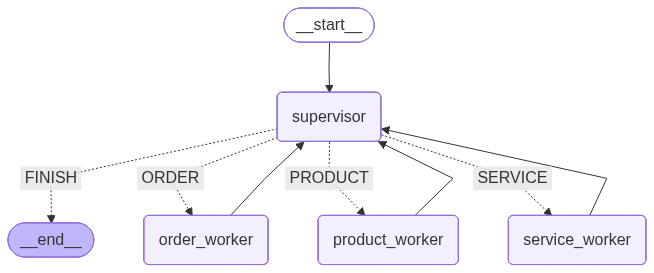

In [22]:
# To see the graph’s connection visually
from IPython.display import Image,display
display(Image(sv_app.get_graph().draw_mermaid_png()))

In [23]:
supervisor_results = []
print('Pattern 3 -- Supervisor')
print('=' * 60)

for i, query in enumerate(TEST_QUERIES, 1):
    start = time.time()
    state = sv_app.invoke({
        'messages': [HumanMessage(content=query)],
        'next_worker': '', 'iteration': 0,
    })
    latency = round(time.time() - start, 2)
    final = state['messages'][-1].content
    supervisor_results.append({
        'query': query, 'answer': final,
        'latency_sec': latency, 'iterations': state.get('iteration', 0),
    })
    print(f'Q{i}: {query}')
    print(f'   Iterations: {state.get("iteration", 0)}')
    print(f'   A: {final[:200]}')
    print(f'   Latency: {latency}s')
    print()

Pattern 3 -- Supervisor
Q1: What is the price of milk and is it in stock?
   Iterations: 2
   A: The price of Great Value Whole Milk (1 gallon) is $3.98. It is currently in stock and can be found in Aisle 12.
   Latency: 5.35s

Q2: I want to return a TV I bought 10 days ago. What is the return policy?
   Iterations: 2
   A: For TVs, which fall under the electronics category, you have 15 days to return the item from the date of purchase. Since you bought the TV 10 days ago, you are within the return window. Please make su
   Latency: 7.18s

Q3: Check my order WM-2024-002.
   Iterations: 2
   A: Your order WM-2024-002 is currently out for delivery and is expected to arrive today by 8 PM.
   Latency: 5.76s

Q4: Find chicken breast and tell me if I can pick it up today.
   Iterations: 2
   A: You can pick up the Great Value Chicken Breast (3 lb) today at Walmart. It's priced at $8.97 and located in Aisle 4.
   Latency: 5.2s

Q5: Do you price match? I saw eggs cheaper at Target.
   Iteratio

## Section 6: Three-Way Comparison

Same queries, three patterns. The numbers below tell you which pattern to use when.

In [24]:
avg_seq = sum(r['latency_sec'] for r in sequential_results) / len(sequential_results)
avg_rtr = sum(r['latency_sec'] for r in router_results)     / len(router_results)
avg_sv  = sum(r['latency_sec'] for r in supervisor_results) / len(supervisor_results)

hdr = f"{'Metric':<35} {'Sequential':>12} {'Router':>10} {'Supervisor':>12}"
print(hdr)
print('-' * len(hdr))
print(f"{'Avg latency (sec)':<35} {avg_seq:>12.2f} {avg_rtr:>10.2f} {avg_sv:>12.2f}")
print(f"{'LLM calls per query (fixed)':<35} {'4':>12} {'2':>10} {'2-4':>12}")
print(f"{'Specialist context size':<35} {'All tools':>12} {'2 tools':>10} {'2 tools':>12}")
print(f"{'Can re-route on failure':<35} {'No':>12} {'No':>10} {'Yes':>12}")
print(f"{'Handles multi-domain queries':<35} {'Yes':>12} {'Partial':>10} {'Yes':>12}")
print(f"{'Audit trail per step':<35} {'Full':>12} {'Partial':>10} {'Full':>12}")
print(f"{'Best for':<35} {'Regulated':>12} {'Simple':>10} {'Complex':>12}")
print(f"{'              ':<35} {'pipelines':>12} {'routing':>10} {'multi-step':>12}")

Metric                                Sequential     Router   Supervisor
------------------------------------------------------------------------
Avg latency (sec)                           5.82       4.34         5.99
LLM calls per query (fixed)                    4          2          2-4
Specialist context size                All tools    2 tools      2 tools
Can re-route on failure                       No         No          Yes
Handles multi-domain queries                 Yes    Partial          Yes
Audit trail per step                        Full    Partial         Full
Best for                               Regulated     Simple      Complex
                                       pipelines    routing   multi-step


## Summary -- Pattern Selection Rubric

| Criterion | Sequential | Router | Supervisor |
|---|---|---|---|
| Query complexity | Fixed steps | Single-domain | Multi-domain |
| Latency priority | Low | High | Medium |
| Audit requirement | Mandatory | Optional | Optional |
| Re-routing needed | No | No | Yes |
| Cost per query | Highest | Lowest | Medium |

**Next: IN06** covers tool integration strategies, agent-to-agent communication protocols,
and failure resilience patterns (timeout, hallucination detection, circuit breaker).